In [2]:
import pandas as pd
import numpy as np

In [36]:
df = pd.read_csv("../u-datasets/mini_1:1_#1.csv")

In [37]:
import pandas as pd
import numpy as np

def hashtag_overlap_matrix(df, hashtag_col="hashtag", user_col="A_id"):
    # Build hashtag -> set of unique users
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", None)
    pd.set_option("display.expand_frame_repr", False)
    hashtag_users = (
        df.groupby(hashtag_col)[user_col]
        .apply(lambda x: set(x.unique()))
        .to_dict()
    )
    
    hashtags = sorted(hashtag_users.keys())
    
    # Print unique recipient counts
    print("Pairwise overlap matrix (1:1)")

    # Initialize zero matrix
    n = len(hashtags)
    overlap_matrix = pd.DataFrame(
        np.zeros((n, n), dtype=int),
        index=hashtags,
        columns=hashtags
    )
    
    # Fill diagonal + upper triangle only
    for i, tag1 in enumerate(hashtags):
        users1 = hashtag_users[tag1]
        overlap_matrix.iloc[i, i] = len(users1)  # diagonal
        
        for j in range(i + 1, n):
            tag2 = hashtags[j]
            users2 = hashtag_users[tag2]
            overlap = len(users1 & users2)
            overlap_matrix.iloc[i, j] = overlap
    
    return overlap_matrix
matrix = hashtag_overlap_matrix(df)
print(matrix)

Pairwise overlap matrix (1:1)
               AI  Anime   ICE  Pokemon  TheTraitors   art  booksky  gaza  olympics  superbowl
AI           4386    939   654      854          350  1137      813   548       337        547
Anime           0   7677  1053     1397          581  1702     1390   923       561        915
ICE             0      0  5238      954          374  1264     1013   738       433        711
Pokemon         0      0     0     7164          503  1528     1339   936       623        931
TheTraitors     0      0     0        0         2326   549      502   320       222        322
art             0      0     0        0            0  8714     1568  1092       657        980
booksky         0      0     0        0            0     0     6912   904       570        876
gaza            0      0     0        0            0     0        0  4839       398        657
olympics        0      0     0        0            0     0        0     0      2614        394
superbowl       0   

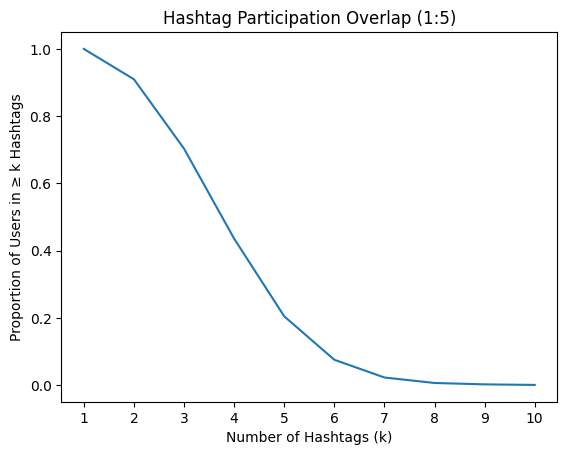

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_hashtag_participation(df, hashtag_col="hashtag", user_col="A_id"):
    
    # Count unique hashtags per user
    user_hashtag_counts = (
        df.groupby(user_col)[hashtag_col]
          .nunique()
    )
    
    total_users = len(user_hashtag_counts)
    max_k = user_hashtag_counts.max()
    
    k_values = list(range(1, max_k + 1))
    proportions = [
        (user_hashtag_counts >= k).sum() / total_users
        for k in k_values
    ]
    
    plt.figure()
    plt.plot(k_values, proportions)
    
    # 👇 Force all integer ticks to show
    plt.xticks(k_values)
    
    plt.xlabel("Number of Hashtags (k)")
    plt.ylabel("Proportion of Users in ≥ k Hashtags")
    plt.title("Hashtag Participation Overlap (1:5)")
    plt.show()


# Run
plot_hashtag_participation(df)